# **A06-FDA-Regulatory-Action-Analysis**

**Team:** A06 | **Course:** BA780 | **Members:** Malak Taoujni, Filip Handjiski, Fan-yu Chiu, Rislyn Raja, Aryan Bajaj

**Data:** FDA Recalls (2012–2026) and FDA Compliance Actions (2008–2026)

**Source:** U.S. Food and Drug Administration, FDA Data Dashboard

**License:** Public domain (U.S. government data)

**Access:** [Recalls](https://datadashboard.fda.gov/oii/cd/recalls.htm) and [Compliance Actions](https://datadashboard.fda.gov/oii/cd/complianceactions.htm) → Export (CSV, ~69 MB and ~17 MB). The notebook loads them from shared Google Drive links.
## Problem Definition
The FDA is obligated to choose where to concentrate monitoring since it has a restricted number of examiners. In order to help determine if the FDA's regulations go where product-safety issues truly occur, this project integrates FDA recall data (unsafe items removed from sale) with compliance action data (warning letters, seizures and injunctions). This is important for customers who depend on safe products and FDA regulators choosing where exactly to conduct inspections. We will:
- Track how recalls have changed over time (2012–2026)
- Compare recalls and compliance actions among different product types and states
- Check to see if there are further recalls at sites that were subject to a compliance action
- Determine which product categories are subject to the most severe actions (injunctions, seizures)

**Success criteria:** Clear, quantitative responses to five questions that provide actionable insights to highlight potential areas for improved FDA supervision.

## Executive Summary
To determine if FDA enforcement goes where safety issues arise, we connected 104,083 FDA recalls with 177,252 compliance actions by facility ID. Devices accounted for 40.5% of recall events (excluding tobacco) but only 15.2% of FDA actions between 2013 and 2025, whereas food and cosmetics got the highest number of actions (38.8%) and 57.6% of all seizures and injunctions. Facilities with a prior compliance action averaged 20.6 recalls, compared with 8.1 for those without. We advise the FDA to prioritize inspections and focus more on medical device manufacturers based on recall history.

## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## Load the Data





In [ ]:
action_df = pd.read_csv("https://drive.google.com/uc?export=download&id=1qxcj1VXfY29P5UAevNNBgp1kNSkPacrL")

recall_df = pd.read_csv("https://drive.google.com/uc?export=download&id=1q-RnBUM8eJ4wtJ50E6jN5U03FAI7XhXq", low_memory=False)

## Initial look at the data
The first five rows, to get a sense of what the columns contain.

In [ ]:
action_df.head()

,FEI Number,Legal Name,State,Country/Area,Product Type,Action Taken Date,Action Type,Case/Injunction ID
0,3049113208,Smoke Shack,New Hampshire,United States,Tobacco,09/17/2026,Warning Letter,738322
1,3030250540,Rey's Mini Market,New Jersey,United States,Tobacco,09/17/2026,Warning Letter,738323
2,3049112976,SMOKE STOP,California,United States,Tobacco,09/17/2026,Warning Letter,738324
3,3020599611,Exxon,Florida,United States,Tobacco,09/17/2026,Warning Letter,738325
4,3048975832,Smokin Glass,Wisconsin,United States,Tobacco,09/17/2026,Warning Letter,738327


In [ ]:
recall_df.head()

,FEI Number,Recalling Firm Name,Product Type,Product Classification,Status,Distribution Pattern,Recalling Firm City,Recalling Firm State,Recalling Firm Country,Center Classification Date,Reason for Recall,Product Description,Event ID,Event Classification,Product ID,Center,Recall Details
0,1216677,"CooperSurgical, Inc.",Devices,Class I,Ongoing,"Nationwide distribution to CT, FL, GA, IA, IL,...",Trumbull,Connecticut,United States,09/18/2026,Potential to exhibit a loose connection betwee...,INCA (Infant Nasal Cannulae Assy) Infant Nasal...,99643,Class I,222061,CDRH,https://www.accessdata.fda.gov/scripts/ires/?P...
1,1216677,"CooperSurgical, Inc.",Devices,Class I,Ongoing,"Nationwide distribution to CT, FL, GA, IA, IL,...",Trumbull,Connecticut,United States,09/18/2026,Potential to exhibit a loose connection betwee...,INCA (Infant Nasal Cannulae Assy) Neonatal Nas...,99643,Class I,222063,CDRH,https://www.accessdata.fda.gov/scripts/ires/?P...
2,1000524567,Evergreen Fresh Sprouts LLC,Food/Cosmetics,Class I,Ongoing,Distributed in WA,Moyie Springs,Idaho,United States,09/18/2026,Salmonella,"Evergreen Fresh Sprouts LLC, Broccoli Sprouts,...",99842,Class I,222720,HFP,https://www.accessdata.fda.gov/scripts/ires/?P...
3,3001451489,"Fresenius Medical Care Renal Therapies Group, LLC",Devices,Class II,Ongoing,Domestic: Nationwide Distribution;,Waltham,Massachusetts,United States,09/18/2026,Communication to recommend reviewing the IFU a...,CombiSet Hemodialysis Blood Tubing Set with At...,99700,Class II,222235,CDRH,https://www.accessdata.fda.gov/scripts/ires/?P...
4,2429304,Olympus Corporation of the Americas,Devices,Class II,Ongoing,International distribution in the country of J...,Center Valley,Pennsylvania,United States,09/18/2026,Potential for the inflation chart label affixe...,Olympus EZDilate Endoscopic Balloon Dilator Wi...,99627,Class II,222014,CDRH,https://www.accessdata.fda.gov/scripts/ires/?P...


## **Data Cleaning**
### Step 1: Before cleaning
Column types, missing counts and dataset size.

In [ ]:
action_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177252 entries, 0 to 177251
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   FEI Number          177252 non-null  int64 
 1   Legal Name          177252 non-null  object
 2   State               177252 non-null  object
 3   Country/Area        177252 non-null  object
 4   Product Type        177252 non-null  object
 5   Action Taken Date   177252 non-null  object
 6   Action Type         177252 non-null  object
 7   Case/Injunction ID  177252 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 10.8+ MB


In [ ]:
recall_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104113 entries, 0 to 104112
Data columns (total 17 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   FEI Number                  104113 non-null  object
 1   Recalling Firm Name         104113 non-null  object
 2   Product Type                104113 non-null  object
 3   Product Classification      104113 non-null  object
 4   Status                      104113 non-null  object
 5   Distribution Pattern        104111 non-null  object
 6   Recalling Firm City         104113 non-null  object
 7   Recalling Firm State        104113 non-null  object
 8   Recalling Firm Country      104113 non-null  object
 9   Center Classification Date  104113 non-null  object
 10  Reason for Recall           104113 non-null  object
 11  Product Description         104113 non-null  object
 12  Event ID                    104113 non-null  int64 
 13  Event Classification        1

In [ ]:
action_df.shape

(177252, 8)

In [ ]:
recall_df.shape

(104113, 17)

### Step 2: Find hidden missing values
The FDA uses "-" for blanks, so we change it to NaN before counting and so that it is recognizable to pandas.

In [ ]:
recall_df = recall_df.replace('-', np.nan)
action_df = action_df.replace('-', np.nan)

print('Missing values in recall_df:', recall_df.isnull().sum())

print('\nMissing values in action_df:', action_df.isnull().sum())

Missing values in recall_df: FEI Number                      30
Recalling Firm Name              0
Product Type                     0
Product Classification           0
Status                           0
Distribution Pattern             2
Recalling Firm City              4
Recalling Firm State          5376
Recalling Firm Country           6
Center Classification Date       0
Reason for Recall               76
Product Description              1
Event ID                         0
Event Classification             0
Product ID                       0
Center                           0
Recall Details                   0
dtype: int64

Missing values in action_df: FEI Number               0
Legal Name               0
State                 2278
Country/Area             2
Product Type             0
Action Taken Date        0
Action Type              0
Case/Injunction ID       0
dtype: int64


### Step 3: Handle missing values
Dropped 30 rows with no FEI Number. Filled missing states with "No US State" (foreign firms) and anything else with "Unknown".

In [ ]:
rows_before = len(recall_df)
recall_df = recall_df.dropna(subset=['FEI Number'])  # Drop rows where FEI number is empty
recall_df['FEI Number'] = recall_df['FEI Number'].astype('int64') # Convert FEI from text to whole number
print('Rows dropped (no FEI Number):', rows_before - len(recall_df))

recall_df['Recalling Firm State'] = recall_df['Recalling Firm State'].fillna('No US State')  # No state = foreign firm
action_df['State'] = action_df['State'].fillna('No US State')
print('Recalls labeled "No US State":', (recall_df['Recalling Firm State'] == 'No US State').sum())
print('Actions labeled "No US State":', (action_df['State'] == 'No US State').sum())

recall_df = recall_df.fillna('Unknown') # Anything else still missing
action_df = action_df.fillna('Unknown')

print('Missing values left in recall_df:', recall_df.isnull().sum().sum())
print('Missing values left in action_df:', action_df.isnull().sum().sum())

Rows dropped (no FEI Number): 30
Recalls labeled "No US State": 5374
Actions labeled "No US State": 2278
Missing values left in recall_df: 0
Missing values left in action_df: 0


### Step 4: Fix dates and add Year

Dates were stored as text, so we convert them and pull out the year for trend analysis.

In [ ]:
recall_df['Center Classification Date'] = pd.to_datetime(recall_df['Center Classification Date'])
action_df['Action Taken Date'] = pd.to_datetime(action_df['Action Taken Date'])

recall_df['Year'] = recall_df['Center Classification Date'].dt.year
action_df['Year'] = action_df['Action Taken Date'].dt.year

recall_df[['Center Classification Date', 'Year']].head()


,Center Classification Date,Year
0,2026-09-18,2026
1,2026-09-18,2026
2,2026-09-18,2026
3,2026-09-18,2026
4,2026-09-18,2026


### Step 5: Check duplicates

In [ ]:
print('Duplicate rows in recall_df:', recall_df.duplicated().sum())
print('Duplicate rows in action_df:', action_df.duplicated().sum())


Duplicate rows in recall_df: 0
Duplicate rows in action_df: 0


### Step 6: After cleaning
No missing values left, and the dates and FEI Number now have the correct types.

In [ ]:
print('RECALLS after cleaning:')
recall_df.info()

print('\nACTIONS after cleaning:')
action_df.info()

# How many facilities appear in both datasets?
both = set(recall_df['FEI Number']) & set(action_df['FEI Number'])
print('\nFacilities in both datasets:', len(both))

RECALLS after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 104083 entries, 0 to 104112
Data columns (total 18 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   FEI Number                  104083 non-null  int64         
 1   Recalling Firm Name         104083 non-null  object        
 2   Product Type                104083 non-null  object        
 3   Product Classification      104083 non-null  object        
 4   Status                      104083 non-null  object        
 5   Distribution Pattern        104083 non-null  object        
 6   Recalling Firm City         104083 non-null  object        
 7   Recalling Firm State        104083 non-null  object        
 8   Recalling Firm Country      104083 non-null  object        
 9   Center Classification Date  104083 non-null  datetime64[ns]
 10  Reason for Recall           104083 non-null  object        
 11  Product Description 

### Step 7: Check for outliers
We count recalls per facility to look for unusually high values.

In [ ]:
recalls_per_facility = recall_df.groupby('FEI Number').size()

print('Recalls per facility (summary):')
print(recalls_per_facility.describe())

print('\nTop 5 facilities by number of recalls:')
print(recalls_per_facility.sort_values(ascending=False).head()) # Sort by frequency so we can see the highest values for outliers

Recalls per facility (summary):
count    10231.000000
mean        10.173297
std         38.121388
min          1.000000
25%          1.000000
50%          2.000000
75%          6.000000
max       1537.000000
dtype: float64

Top 5 facilities by number of recalls:
FEI Number
1417592       1537
1000220733     860
1825034        716
2648727        682
2129071        634
dtype: int64


One facility (Medline Industries) has 1,537 recalls, while most have 1–6 recalls (median 2). Since these outliers are actual repeat offenders rather than data mistakes, we **kept them**. We count by **FEI Number** rather than corporate name as the same facility may potentially appear under other spellings.

### Step 8: Join the two datasets by FEI Number
We count recalls and actions per facility and join them into one table, which we use in Q4.

In [ ]:
recall_counts = pd.DataFrame({'Recall Count': recall_df['FEI Number'].value_counts()})
action_counts = pd.DataFrame({'Action Count': action_df['FEI Number'].value_counts()})

# Join the two tables by FEI Number
facility_df = recall_counts.join(action_counts)

# Facilities with no actions get 0
facility_df = facility_df.fillna(0)
facility_df['Had Action'] = facility_df['Action Count'] > 0

print(facility_df['Had Action'].value_counts())
facility_df.head()

Had Action
False    8507
True     1724
Name: count, dtype: int64


,Recall Count,Action Count,Had Action
FEI Number,,,
1417592,1537,2.0,True
1000220733,860,0.0,False
1825034,716,2.0,True
2648727,682,2.0,True
2129071,634,1.0,True


### Data Dictionary
| Dataset | Column | Meaning | Type |
|---|---|---|---|
| Both | FEI Number | Unique FDA facility ID (links the datasets) | int |
| Recalls | Product Type | Devices, Food/Cosmetics, Drugs, Biologics, Veterinary, Tobacco | text |
| Recalls | Product Classification | Severity: Class I (most serious), II, III | text |
| Recalls | Event ID | One recall event (can cover several products) | int |
| Recalls | Recalling Firm State | U.S. state ("No US State" = foreign firm) | text |
| Recalls | Center Classification Date | Date the FDA classified the recall | datetime |
| Compliance | Product Type | Product area (94% Tobacco) | text |
| Compliance | Action Type | Warning Letter, Seizure, Injunction | text |
| Compliance | State | U.S. state ("No US State" = foreign firm) | text |
| Compliance | Action Taken Date | Date of the action | datetime |
| Both | Year | Year taken from the date (added by us) | int |

### Cleaning Process Log

| Dataset | Column | Issue | Action | Justification |
|---|---|---|---|---|
| Both | All | "-" used instead of blanks | Replaced with NaN | So pandas counts them as missing |
| Recalls | FEI Number | 30 missing, stored as text | Dropped rows, converted to integer | Needed to link datasets; <0.03% of rows |
| Both | State | 5,374 recall / 2,278 action values missing | Filled "No US State" | Mostly foreign firms |
| Recalls | City, Country, Reason, Description, Distribution | 89 missing | Filled "Unknown" | Tiny share; keep rows |
| Both | Dates | Stored as text | Converted to datetime, added Year | Needed for trends over time |
| Both | All | Duplicates checked | None found | Each row is unique |
| Recalls | Recalls per facility | Outliers (max 1,537 vs median 2) | Kept | Real repeat offenders |
| Recalls | Firm Name | Same facility spelled differently | Counted by FEI Number | Avoids double counting |
| Both | FEI Number | Two separate datasets | Joined into facility_df | Compare recalls vs. actions per facility |

> **So what:** The majority of the data was complete. We have 104,083 recalls and 177,252 actions with no missing values after correcting "-" values and date types. Additionally, 1,724 facilities are present in both datasets.


## **Exploratory Analysis Questions**
To produce a clear image regarding the analysis, Q1 looks at recall trends, Q2–Q4 combine both datasets, and Q5 looks at the harshest actions. Q2 and Q3 count each recall event once and use full years only (2013–2025) for a fair comparison.

## Q1: How has the number of FDA recalls changed from 2012 to 2026?
**Who cares:** FDA regulators, to see whether product-safety problems are growing or shrinking over time.

Year
2012    5549
2013    8565
2014    7871
2015    8508
2016    8935
2017    7933
2018    8321
2019    8274
2020    6224
2021    5278
2022    5769
2023    6726
2024    6301
2025    5583
2026    4246
dtype: int64


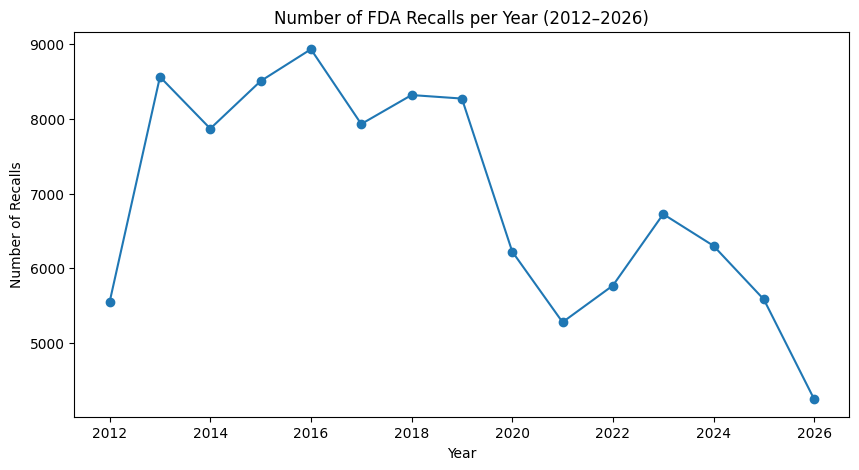

In [ ]:
recalls_per_year = recall_df.groupby('Year').size()
print(recalls_per_year)

# Line chart
recalls_per_year.plot(kind='line', marker='o', figsize=(10, 5), title='Number of FDA Recalls per Year (2012–2026)')
plt.xlabel('Year')
plt.ylabel('Number of Recalls')
plt.show()

>**So what:** After peaking at 8,935 in 2016, recalls have mostly decreased since then, reaching a low of 5,278 in 2021. 2026's count isn't a true decline because it's only through September.

>**Caveat:** 2012 and 2026 are partial years (data runs June 2012 – Sept 2026), and the 2020–21 dip may reflect COVID-era inspection slowdowns rather than safer products.

## Q2: Leaving out tobacco, do the product types with the most recall events also have the most FDA actions?
**Who cares:** FDA regulators, because this comparison helps show where recall activity and regulatory actions are concentrated.

                Recall events  FDA actions
Product Type                              
Biologics                22.9          2.3
Devices                  40.5         15.2
Drugs                    12.7         33.8
Food/Cosmetics           21.5         38.8
Veterinary                2.4          9.8


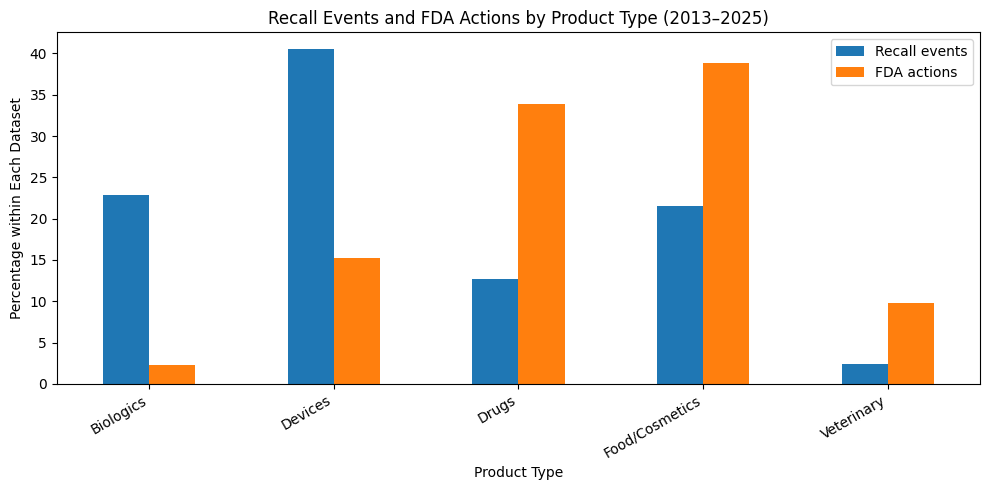

In [ ]:
# Keep 2013–2025 and leave out tobacco
actions = action_df[
    (action_df["Action Taken Date"].dt.year.between(2013, 2025)) &
    (action_df["Product Type"] != "Tobacco")
]

recalls = recall_df[
    (recall_df["Center Classification Date"].dt.year.between(2013, 2025)) &
    (recall_df["Product Type"] != "Tobacco")
]

# One recall event can have several product rows, so count it once
recalls = recalls.drop_duplicates(subset="Event ID")

# Count each product type
recall_counts = recalls["Product Type"].value_counts()
action_counts = actions["Product Type"].value_counts()

# Turn the counts into percentages
recall_percent = recall_counts / recall_counts.sum() * 100
action_percent = action_counts / action_counts.sum() * 100

# Put the two percentages side by side
comparison = pd.DataFrame({
    "Recall events": recall_percent,
    "FDA actions": action_percent
})

print(comparison.round(1))

# Make the chart
comparison.plot(kind="bar", figsize=(10, 5))
plt.title("Recall Events and FDA Actions by Product Type (2013–2025)")
plt.xlabel("Product Type")
plt.ylabel("Percentage within Each Dataset")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

  > **So what:** Devices had the largest share of recall events (40.5%), while Food/Cosmetics had the largest share of FDA actions (38.8%). The product type with the most recalls was different from the one with the most actions.

  > **Caveat:** Many recalls are voluntary, so a recall doesn't necessarily lead to FDA action.

## Q3: Leaving out tobacco, do the states with the most recall events also have the most FDA actions?
**Who cares:** FDA regulators, to see whether inspections and actions are focused on the same states where recalls happen most.

               Recall events  FDA actions
California              12.6         16.7
New Jersey               7.4          4.4
Florida                  7.0          8.5
Pennsylvania             5.8          3.8
Illinois                 5.7          3.2
New York                 5.5          8.2
Texas                    5.0          7.8
Massachusetts            4.8          2.0
Ohio                     4.0          2.6
Minnesota                3.9          1.6


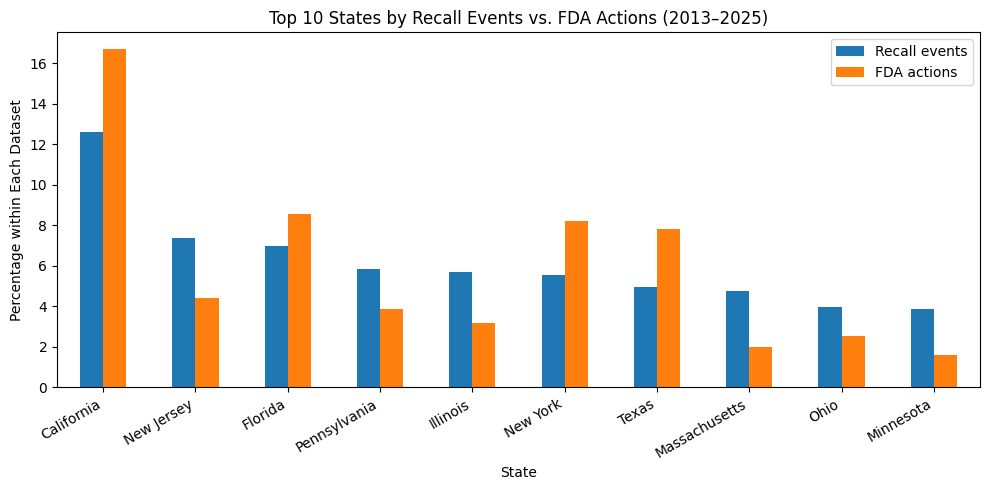

In [ ]:
# Keep 2013–2025, leave out tobacco and firms with no US state
state_recalls = recall_df[
    (recall_df["Year"].between(2013, 2025)) &
    (recall_df["Product Type"] != "Tobacco") &
    (recall_df["Recalling Firm State"] != "No US State")
]

state_actions = action_df[
    (action_df["Year"].between(2013, 2025)) &
    (action_df["Product Type"] != "Tobacco") &
    (action_df["State"] != "No US State")
]

# One recall event can have several product rows, so count it once
state_recalls = state_recalls.drop_duplicates(subset="Event ID")

# Count each state and turn into percentages
recall_state_pct = state_recalls["Recalling Firm State"].value_counts() / len(state_recalls) * 100
action_state_pct = state_actions["State"].value_counts() / len(state_actions) * 100

# Put the two side by side and keep the top 10 states by recall events
state_comparison = pd.DataFrame({
    "Recall events": recall_state_pct,
    "FDA actions": action_state_pct
}).fillna(0)

top_states = state_comparison.sort_values("Recall events", ascending=False).head(10)
print(top_states.round(1))

# Make the chart
top_states.plot(kind="bar", figsize=(10, 5))
plt.title("Top 10 States by Recall Events vs. FDA Actions (2013–2025)")
plt.xlabel("State")
plt.ylabel("Percentage within Each Dataset")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

> **So what:** California leads both, with 12.6% of recall events and 16.7% of FDA actions. Some states don't match: New Jersey, Massachusetts and Minnesota have a much larger share of recalls than actions, while New York, Texas and Florida have a larger share of actions than recalls.

>**Caveat:** Firms are counted by headquarters state, which may not be where the problem product was made or sold exactly.

## Q4: Do facilities that received a compliance action also have more recalls?
**Who cares:** FDA regulators, to see whether facilities that were already warned or penalized keep having safety problems.

No Action      8.1
Had Action    20.6
Name: Recall Count, dtype: float64


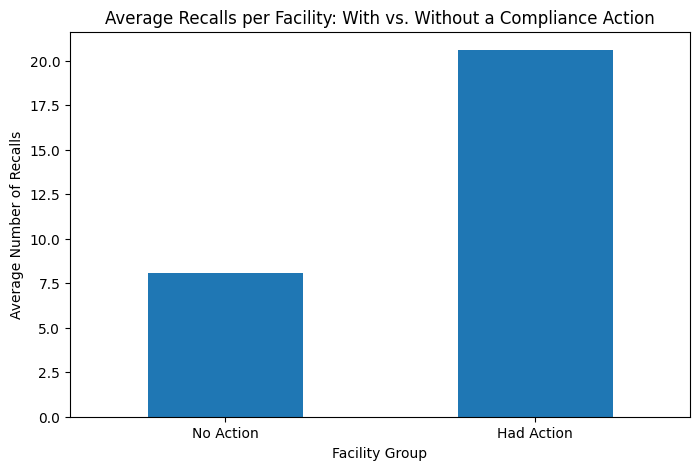

In [ ]:
# Average number of recalls per facility, with vs. without a compliance action
avg_recalls = facility_df.groupby('Had Action')['Recall Count'].mean().round(1)
avg_recalls.index = ['No Action', 'Had Action']   # False = No Action, True = Had Action
print(avg_recalls)

# Bar chart
avg_recalls.plot(kind='bar', figsize=(8, 5), title='Average Recalls per Facility: With vs. Without a Compliance Action')
plt.xlabel('Facility Group')
plt.ylabel('Average Number of Recalls')
plt.xticks(rotation=0)
plt.show()

> **So what:** Facilities that received a compliance action average 20.6 recalls compared with only 8.1 for facilities without one, which suggests the FDA should keep monitoring these facilities closely after taking action.

> **Caveat:** This shows a link, not a cause. Larger facilities make more products, so they may simply have more recalls and more actions.

## Q5: Apart from tobacco, which product types get the harshest FDA actions (seizures and injunctions)?
**Who cares:** FDA regulators, to see which product categories draw the most serious enforcement, and companies in those categories, who face the highest compliance risk.



Action Type     Injunction  Seizure
Product Type                       
Food/Cosmetics         131       51
Drugs                   48       24
Veterinary              32        1
Devices                 20        5
Biologics                3        1

Share of all harsh actions (%):
Product Type
Food/Cosmetics    57.6
Drugs             22.8
Veterinary        10.4
Devices            7.9
Biologics          1.3
dtype: float64


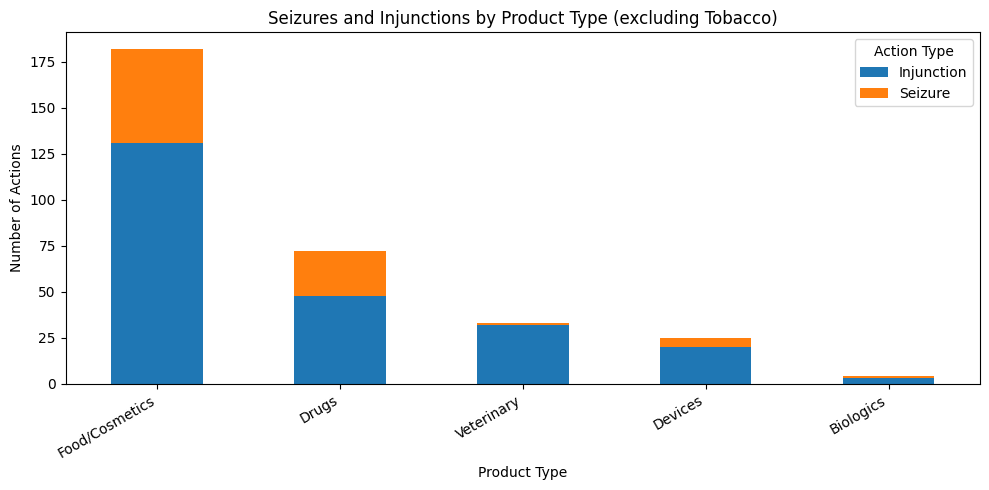

In [ ]:
# Leave out tobacco and keep only the harshest actions
harsh = action_df[
    (action_df["Product Type"] != "Tobacco") &
    (action_df["Action Type"].isin(["Injunction", "Seizure"]))
]

# Count actions by product type (bars) and action type (stacks)
harsh_counts = pd.crosstab(harsh["Product Type"], harsh["Action Type"])

# Sort so the product type with the most harsh actions comes first
harsh_counts = harsh_counts.loc[harsh_counts.sum(axis=1).sort_values(ascending=False).index]
print(harsh_counts)
print("\nShare of all harsh actions (%):") # Calculating percentages
print((harsh_counts.sum(axis=1) / harsh_counts.sum().sum() * 100).round(1))

# Stacked bar chart
harsh_counts.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("Seizures and Injunctions by Product Type (excluding Tobacco)")
plt.xlabel("Product Type")
plt.ylabel("Number of Actions")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Action Type")
plt.tight_layout()
plt.show()

> **So what:** Food/Cosmetics received the harshest FDA actions with 182 of the 316 seizures and injunctions (57.6%), followed by Drugs (22.8%) and Veterinary (10.4%).

>**Caveat:** Seizures and injunctions are rare (316 in total), so a few cases can shift these percentages a lot.

## Conclusion
1. **Use recall history to target inspections.** Facilities with a past compliance action average 2.5x more recalls (20.6 vs. 8.1). *(Impact: High / Feasibility: High)*
2. **Increase oversight of medical devices.** Excluding tobacco, devices had the largest share of recall events, 40.5%, but only 15.2% of FDA actions (2013–2025). *(Impact: High / Feasibility: Medium)*
3. **Rebalance attention across states.** New Jersey (7.4% of recall events vs. 4.4% of actions), Massachusetts (4.8% vs. 2.0%) and Minnesota (3.9% vs. 1.6%) get less enforcement than their recall share suggests. *(Impact: Medium / Feasibility: Medium)*
4. **Keep strong food enforcement.** Food/Cosmetics already receives 57.6% of all seizures and injunctions (182 of 316). *(Impact: Medium / Feasibility: High)*

**Risks/limits:** Results show links, not causes. 94% of compliance actions are tobacco, 2012 and 2026 are partial years (data runs June 2012 – Sept 2026), and many recalls are voluntary, so not every recall leads to FDA action.

**Next steps:** Add FDA inspection data, analyze recall reasons (e.g., Listeria, undeclared allergens), and test if recalls drop after a warning letter.

## References
- U.S. Food and Drug Administration. *FDA Data Dashboard – Recalls.* https://datadashboard.fda.gov/oii/cd/recalls.htm (accessed Sept 2026)
- U.S. Food and Drug Administration. *FDA Data Dashboard – Compliance Actions.* https://datadashboard.fda.gov/oii/cd/complianceactions.htm (accessed Sept 2026)
- pandas documentation: https://pandas.pydata.org/docs/
- matplotlib documentation: https://matplotlib.org/stable/

## Generative AI Disclosure
We used Claude (Anthropic) to brainstorm any additional data-cleaning steps, troubleshoot errors in code output, structure the data cleaning log and data dictionary, likewise lay out the references and conclusion with a given text. In addition, AI was used to run and check the notebook once it was finished for possible troubleshooting. Subsequently, all code was run and checked by the team in Google Colab, every number reported comes from our notebook output, and the team reviewed and edited all written text.